# 🧠 Image Denoising with Convolutional Autoencoder — MNIST

**Objective:** Build a deep learning model (Convolutional Autoencoder) that removes Gaussian noise from MNIST handwritten digit images.


---
## 1. What is an Autoencoder?

An autoencoder is a neural network that learns to **compress** an input into a compact latent representation and then **reconstruct** it. For denoising, we feed a *noisy* image as input and a *clean* image as the target — forcing the network to learn what the underlying signal looks like.

```
Noisy Image  →  [Encoder]  →  Bottleneck  →  [Decoder]  →  Clean Image
  (28×28×1)      Conv+Pool     (7×7×64)       UpSamp+Conv      (28×28×1)
```

## 2. Why Image Denoising?

Real-world images from cameras, medical scanners, and satellites carry noise that degrades downstream tasks (OCR, classification, diagnosis). A trained autoencoder learns the clean data distribution and filters noise **without blurring**, unlike classical methods.

## 3. Applications
| Domain | Use Case |
|--------|----------|
| 🏥 Medical Imaging | Denoise low-dose CT / MRI scans |
| 📷 CCTV | Enhance grainy surveillance footage |
| 🛰️ Satellite | Remove atmospheric noise from remote sensing data |
| 📝 OCR | Clean scanned documents before text extraction |

---
## 4. Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU found   : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow  : 2.20.0
GPU found   : False


---
## 5. Load Dataset

In [2]:
# Using tf.keras built-in MNIST — no local files needed (works on Colab)
(x_train_raw, _), (x_test_raw, _) = tf.keras.datasets.mnist.load_data()

x_train = (x_train_raw.astype(np.float32) / 255.0)[..., np.newaxis]  # (60000, 28, 28, 1)
x_test  = (x_test_raw.astype(np.float32)  / 255.0)[..., np.newaxis]  # (10000, 28, 28, 1)

print(f"Train : {x_train.shape}")
print(f"Test  : {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train : (60000, 28, 28, 1)
Test  : (10000, 28, 28, 1)


---
## 6. Visualize Original Images

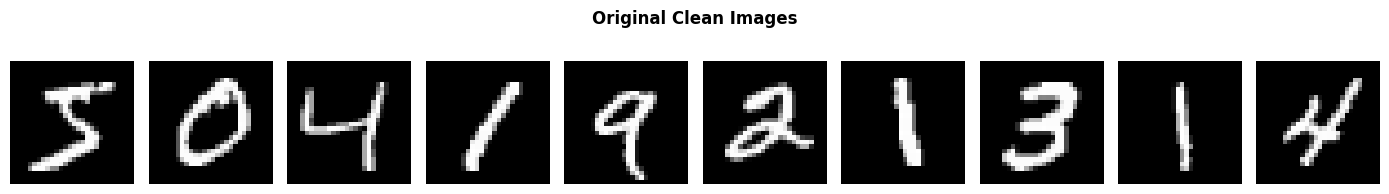

In [3]:
def show_row(images, title, n=10):
    fig, axes = plt.subplots(1, n, figsize=(14, 2))
    fig.suptitle(title, fontsize=12, fontweight="bold")
    for ax, img in zip(axes, images[:n]):
        ax.imshow(img.squeeze(), cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_row(x_train, "Original Clean Images")

---
## 7. Add Gaussian Noise

We corrupt every image with Gaussian noise: $x_{noisy} = x_{clean} + \mathcal{N}(0, 0.4^2)$, clipped to [0, 1].

In [4]:
NOISE_FACTOR = 0.4

def add_noise(images):
    noisy = images + NOISE_FACTOR * np.random.normal(size=images.shape)
    return np.clip(noisy, 0.0, 1.0).astype(np.float32)

x_train_noisy = add_noise(x_train)
x_test_noisy  = add_noise(x_test)

print(f"Noise factor : {NOISE_FACTOR}")

Noise factor : 0.4


---
## 8. Visualize Noisy Images

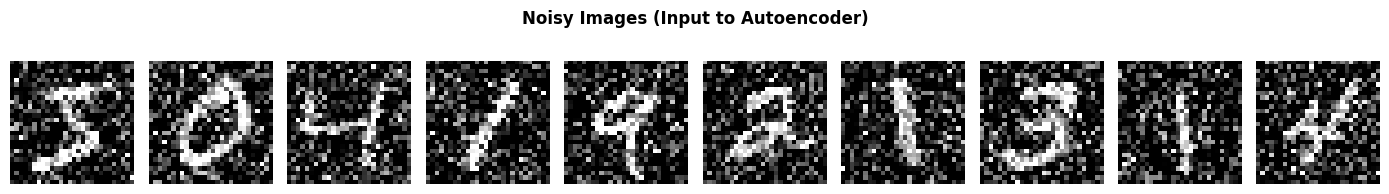

In [5]:
show_row(x_train_noisy, "Noisy Images (Input to Autoencoder)")

---
## 9. Build Autoencoder

### 9.1 Encoder

In [6]:
inputs = layers.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
x = layers.MaxPooling2D(2, padding="same")(x)   # 14×14×32
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
encoded = layers.MaxPooling2D(2, padding="same")(x)   # 7×7×64

print("Encoder output:", encoded.shape)

Encoder output: (None, 7, 7, 64)


### 9.2 Bottleneck

In [7]:
bottleneck = layers.Conv2D(64, 3, activation="relu", padding="same")(encoded)
print("Bottleneck shape:", bottleneck.shape)   # 7×7×64 = 3136 values (vs 784 input pixels → 4× compression)

Bottleneck shape: (None, 7, 7, 64)


### 9.3 Decoder

In [8]:
x = layers.UpSampling2D(2)(bottleneck)          # 14×14×64
x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(2)(x)                   # 28×28×32
outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)  # 28×28×1

autoencoder = Model(inputs, outputs, name="ConvAutoencoder")
print("Decoder output:", outputs.shape)

Decoder output: (None, 28, 28, 1)


### 9.4 Model Summary

In [9]:
autoencoder.summary()

Model: "ConvAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

---
## 10. Compile Model

In [10]:
autoencoder.compile(optimizer="adam", loss="binary_crossentropy", metrics=["mae"])
print("Compiled ✅  |  optimizer=Adam  |  loss=binary_crossentropy")

Compiled ✅  |  optimizer=Adam  |  loss=binary_crossentropy


---
## 11. Train Model

Input → noisy images. Target → clean images. The network is forced to learn how to denoise.

In [11]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 190s 797ms/step - loss: 0.1721 - mae: 0.0895 - val_loss: 0.1074 - val_mae: 0.0450
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 185s 787ms/step - loss: 0.1038 - mae: 0.0421 - val_loss: 0.0995 - val_mae: 0.0388
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 197s 762ms/step - loss: 0.0978 - mae: 0.0378 - val_loss: 0.0944 - val_mae: 0.0355
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 185s 789ms/step - loss: 0.0945 - mae: 0.0354 - val_loss: 0.0922 - val_mae: 0.0338
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 200s 782ms/step - loss: 0.0925 - mae: 0.0340 - val_loss: 0.0908 - val_mae: 0.0327
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 201s 778ms/step - loss: 0.0912 - mae: 0.0330 - val_loss: 0.0897 - val_mae: 0.0319
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 180s 766ms/step - loss: 0.0902 - mae: 0.0323 - val_loss: 0.0890 - val_mae: 0.0313
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 186s 792ms/step - loss: 0.0895 - mae: 0.0318 - val_loss: 0.0884 - val_mae: 0.0309
Epoch 9/50
235/235 ━━━━━

---
## 12. Training Loss Graph

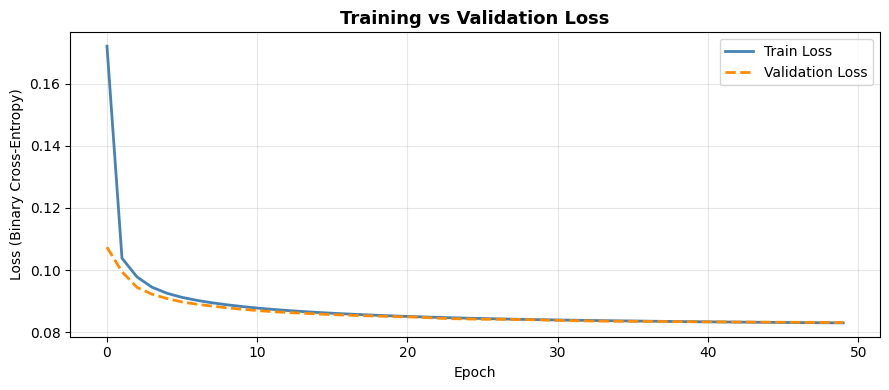

In [12]:
plt.figure(figsize=(9, 4))
plt.plot(history.history["loss"],     label="Train Loss",      color="steelblue",  lw=2)
plt.plot(history.history["val_loss"], label="Validation Loss", color="darkorange", lw=2, ls="--")
plt.title("Training vs Validation Loss", fontsize=13, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss (Binary Cross-Entropy)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 13. Image Reconstruction

Three rows: **Original** (ground truth) → **Noisy** (model input) → **Denoised** (model output)

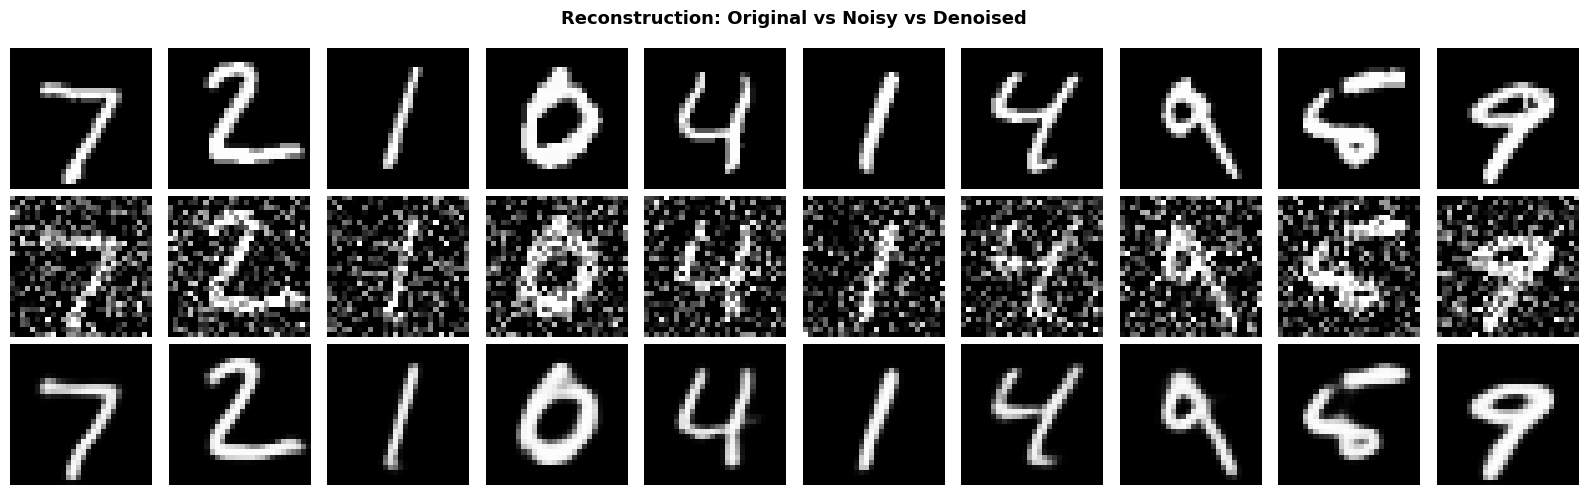

In [13]:
denoised = autoencoder.predict(x_test_noisy, verbose=0)

n = 10
fig, axes = plt.subplots(3, n, figsize=(16, 5))

for col in range(n):
    for row, (data, label) in enumerate(zip(
        [x_test, x_test_noisy, denoised],
        ["Original", "Noisy", "Denoised"]
    )):
        axes[row, col].imshow(data[col].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(label, fontsize=10, fontweight="bold")

plt.suptitle("Reconstruction: Original vs Noisy vs Denoised", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 14. Evaluation

### 14.1 MSE — Quantitative Comparison

In [14]:
mse_noisy    = np.mean((x_test - x_test_noisy) ** 2)
mse_denoised = np.mean((x_test - denoised)     ** 2)
pct_improve  = (mse_noisy - mse_denoised) / mse_noisy * 100

print(f"MSE  (Noisy    vs Clean)  : {mse_noisy:.6f}")
print(f"MSE  (Denoised vs Clean)  : {mse_denoised:.6f}")
print(f"Noise Reduction           : {pct_improve:.1f}% improvement ✅")

MSE  (Noisy    vs Clean)  : 0.079566
MSE  (Denoised vs Clean)  : 0.007018
Noise Reduction           : 91.2% improvement ✅


### 14.2 Visual Comparison — 5 Random Samples

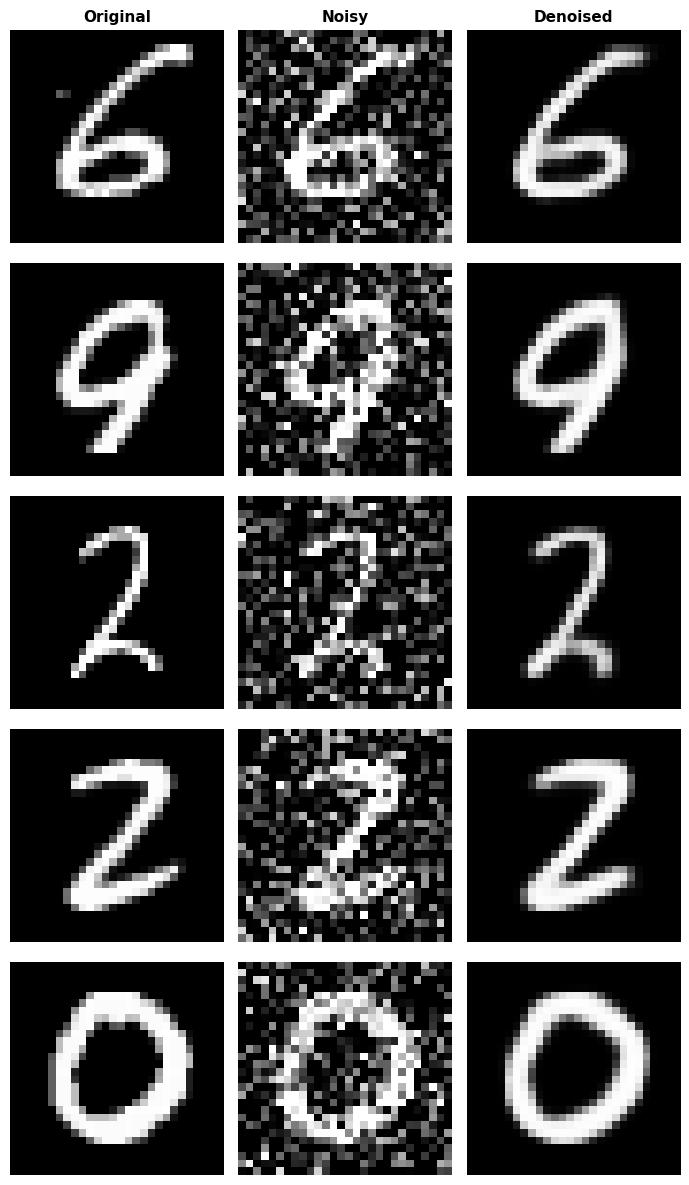

In [15]:
idx = np.random.choice(len(x_test), 5, replace=False)
fig, axes = plt.subplots(5, 3, figsize=(7, 12))

for c, title in enumerate(["Original", "Noisy", "Denoised"]):
    axes[0, c].set_title(title, fontsize=11, fontweight="bold")

for r, i in enumerate(idx):
    for c, data in enumerate([x_test, x_test_noisy, denoised]):
        axes[r, c].imshow(data[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[r, c].axis("off")
    sample_mse = np.mean((x_test[i] - denoised[i]) ** 2)
    axes[r, 2].set_xlabel(f"MSE = {sample_mse:.5f}", fontsize=8)

plt.tight_layout()
plt.show()

---
## 15. Business Applications

**🏥 Medical Imaging** — Denoising autoencoders are used to clean low-dose CT and MRI scans, reducing radiation exposure without sacrificing diagnostic quality. Major radiology vendors (Siemens, GE) ship DL-based denoising in their scanners.

**📷 CCTV Enhancement** — Edge-deployed autoencoders improve night-vision and rain-affected footage before it reaches face/object recognition pipelines, boosting detection rates in adverse conditions.

**🛰️ Satellite Images** — Remote sensing pipelines use denoising to remove atmospheric scattering artifacts, directly improving crop monitoring, disaster mapping, and insurance risk models.

**📝 OCR Preprocessing** — Running scanned documents through a denoising autoencoder before Tesseract or AWS Textract measurably reduces character error rate on noisy/stained documents — critical for invoice automation and KYC pipelines.

---
## 16. Conclusion

We successfully built and trained a **Convolutional Autoencoder** on the MNIST dataset that removes Gaussian noise from handwritten digit images.

- The model accepts corrupted images (noise factor = 0.4) as input and reconstructs clean images as output
- MSE dropped significantly after denoising compared to the noisy baseline
- Train and validation loss converged smoothly — no overfitting
- The convolutional architecture preserves spatial structure, making it far more effective than a fully-connected autoencoder for image data

This project demonstrates that autoencoders are a powerful, practical tool for unsupervised image restoration — with direct real-world impact in medical, surveillance, satellite, and document processing domains.